Lab 21.2 – t-SNE
Goal: Use t‑SNE to project high‑D data into 2D for visualization. You’ll:

Load embeddings (MNIST pixels or any vectors),

(Optionally) pre‑reduce with PCA,

Run t‑SNE with sensible hyperparameters,

Compare perplexities/learning rates,

Diagnose artifacts, and

Contrast with PCA/UMAP (optional).

t‑SNE is for visualization, not clustering. Distances/areas are not linear; global structure can be distorted.

In [1]:
# pip install scikit-learn matplotlib seaborn numpy
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(0)

In [2]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)   # (70000, 784)
y = mnist.target.astype(int)
# Subsample for speed
N = 10000
idx = np.random.choice(len(X), size=N, replace=False)
X, y = X[idx], y[idx]
# Standardize (center/scale features)
X_std = StandardScaler().fit_transform(X)
X_std.shape, np.bincount(y)

((10000, 784),
 array([ 996, 1141, 1040, 1013,  962,  863,  989, 1064,  963,  969]))

2) Optional: PCA pre‑reduction (denoise & speed t‑SNE)
Common practice: PCA → 50 dims before t‑SNE

In [3]:
pca = PCA(n_components=50, random_state=0).fit(X_std)
X50 = pca.transform(X_std)
print("Explained variance (50 PCs):", round(pca.explained_variance_ratio_.sum(), 3))

Explained variance (50 PCs): 0.582


3) Baseline t‑SNE (2D)
Use perplexity ~ 30, learning_rate ~ 200 as a starting point.

In [10]:
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
             init='pca', random_state=0, verbose=1)
Z = tsne.fit_transform(X50)   # or X_std, but X50 is typically better
print("t-SNE time (s):", round(time.time()-t0, 1))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1797 samples in 0.001s...
[t-SNE] Computed neighbors for 1797 samples in 1.899s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1797
[t-SNE] Computed conditional probabilities for sample 1797 / 1797
[t-SNE] Mean sigma: 11.583851
[t-SNE] KL divergence after 250 iterations with early exaggeration: 61.434326
[t-SNE] KL divergence after 1000 iterations: 0.739674
t-SNE time (s): 11.5


Plot (color by digit):

Shape of Z: (1797, 2)
Shape of y: (1797,)


<Figure size 700x600 with 0 Axes>

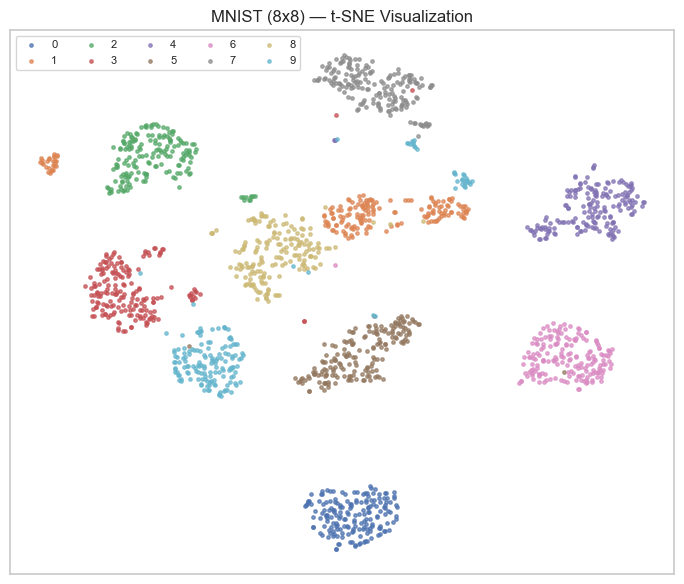

In [15]:
from sklearn.datasets import load_digits

# 1. Load the labels specifically for the 1797-sample dataset
digits = load_digits()
y = digits.target  # This will have shape (1797,)

plt.figure(figsize=(7,6))
print(f"Shape of Z: {Z.shape}")  # Should be (1797, 2)
print(f"Shape of y: {y.shape}")  # Should be (1797,)
# 2. Run the plot loop
if len(y) == len(Z):
    plt.figure(figsize=(7,6))
    
    # Loop through digits 0-9
    for d in range(10):
        # Boolean indexing now works because shapes match
        pts = Z[y == d]
        plt.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.7, label=str(d))

    plt.title('MNIST (8x8) — t-SNE Visualization')
    plt.legend(ncol=5, fontsize=8)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("Error: Shapes still do not match. Please regenerate Z using the same dataset as y.")

4) Hyperparameters: perplexity sweep

Perplexity ~ “effective #neighbors.” Too small → fragmented; too large → washed out.

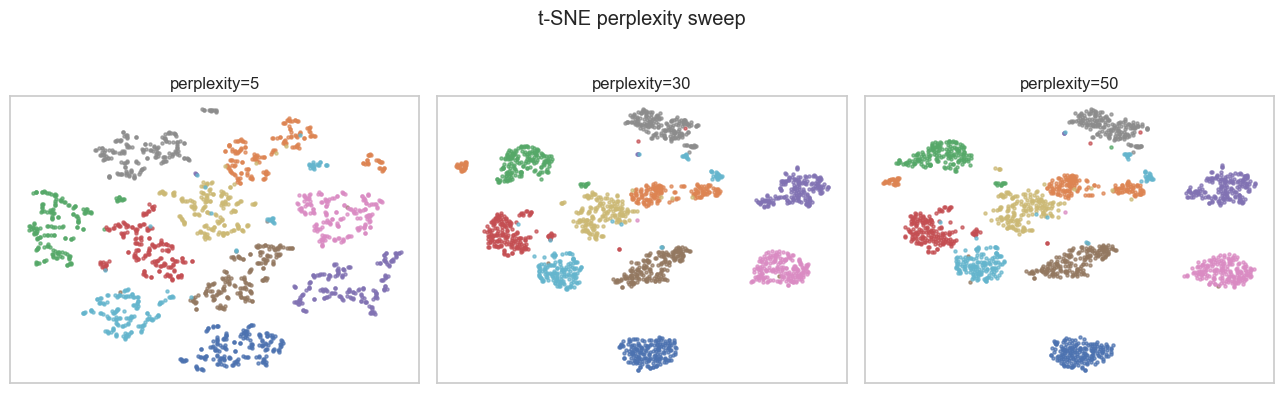

In [17]:
perps = [5, 30, 50]
embeds = {}
for p in perps:
    Zp = TSNE(n_components=2, perplexity=p, learning_rate=200, 
              init='pca', random_state=0).fit_transform(X50)
    embeds[p] = Zp

fig, axes = plt.subplots(1, len(perps), figsize=(13,4))
for ax, p in zip(axes, perps):
    Zp = embeds[p]
    for d in range(10):
        pts = Zp[y==d]
        ax.scatter(pts[:,0], pts[:,1], s=5, alpha=0.7)
    ax.set_title(f'perplexity={p}'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('t-SNE perplexity sweep'); plt.tight_layout(rect=[0,0,1,0.95]); plt.show()

5) Hyperparameters: learning rate & iterations
Too small LR → points collapse; too big → blow apart.

More iterations can stabilize local structure.

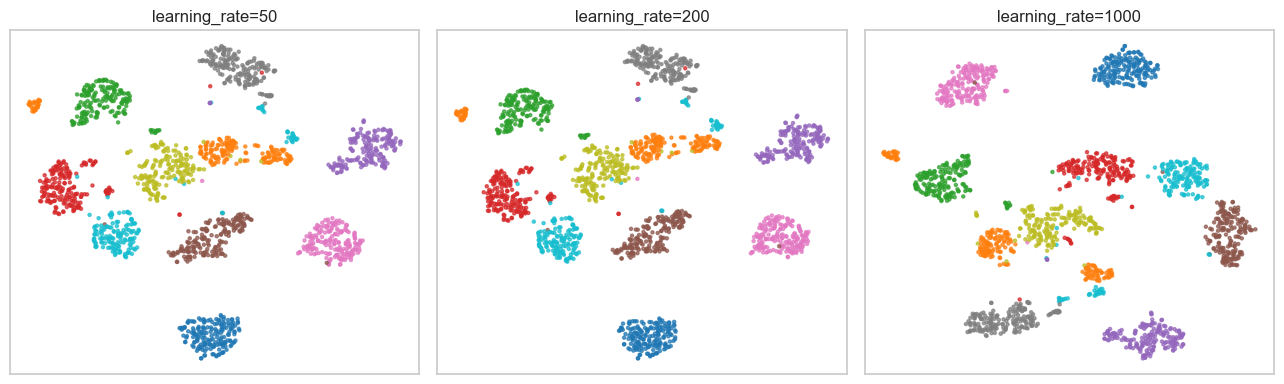

In [19]:
lrs = [50, 200, 1000]
fig, axes = plt.subplots(1, len(lrs), figsize=(13,4))
for ax, lr in zip(axes, lrs):
    Zlr = TSNE(n_components=2, perplexity=30, learning_rate=lr,
               init='pca', random_state=0).fit_transform(X50)
    ax.scatter(Zlr[:,0], Zlr[:,1], c=y, s=5, alpha=0.7, cmap='tab10')
    ax.set_title(f'learning_rate={lr}'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

6) Compare to PCA‑2D (global vs local structure)

ValueError: 'c' argument has 1797 elements, which is inconsistent with 'x' and 'y' with size 10000.

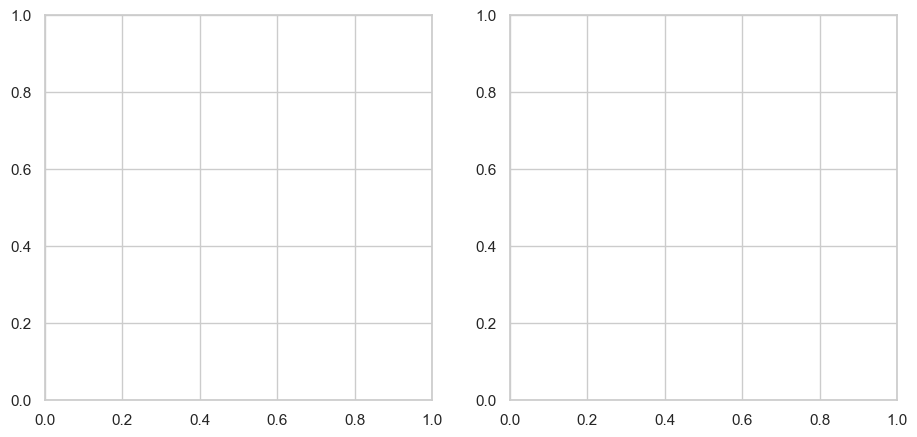

In [20]:
Zpca = PCA(n_components=2, random_state=0).fit_transform(X_std)
fig, axes = plt.subplots(1,2, figsize=(11,5))
axes[0].scatter(Zpca[:,0], Zpca[:,1], c=y, s=5, alpha=0.7, cmap='tab10')
axes[0].set_title('PCA (2D)'); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].scatter(Z[:,0], Z[:,1], c=y, s=5, alpha=0.7, cmap='tab10')
axes[1].set_title('t-SNE (2D)'); axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

7) (Optional) UMAP comparison

In [3]:
# pip install umap-learn
import umap
um = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0)
Zu = um.fit_transform(X50)
plt.figure(figsize=(6,5))
plt.scatter(Zu[:,0], Zu[:,1], c=y, s=5, alpha=0.7, cmap='tab10')
plt.title('UMAP (2D)'); plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

C:\Users\PRASAD\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'X50' is not defined